In [54]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal

In [55]:
class Quadratic(TypedDict):
    a:int
    b:int
    c:int

    equation:str
    discriminant:float
    result:str


In [56]:
def show_equ(state:Quadratic):
    equation=f'{state['a']}x2{state['b']}x{state['c']}'
    return {'equation':equation}

In [57]:
def discriminent_equ(state:Quadratic):
    discriminant = state["b"]**2 - (4*state["a"]*state["c"])

    return {'discriminant': discriminant}


In [58]:
def real_roots(state: Quadratic):

    root1 = (-state["b"] + state["discriminant"]**0.5)/(2*state["a"])
    root2 = (-state["b"] - state["discriminant"]**0.5)/(2*state["a"])

    result = f'The roots are {root1} and {root2}'

    return {'result': result}

In [59]:
def repeated_roots(state: Quadratic):

    root = (-state["b"])/(2*state["a"])

    result = f'Only repeating root is {root}'

    return {'result': result}


In [60]:
def no_real_roots(state: Quadratic):

    result = f'No real roots'

    return {'result': result}

In [61]:
def check_condition(state: Quadratic) -> Literal["real_roots", "repeated_roots", "no_real_roots"]:

    if state['discriminant'] > 0:
        return "real_roots"
    elif state['discriminant'] == 0:
        return "repeated_roots"
    else:
        return "no_real_roots"

In [62]:
graph=StateGraph(Quadratic)
graph.add_node('show_equ',show_equ)
graph.add_node('discriminent_equ',discriminent_equ)
graph.add_node('real_roots',real_roots)
graph.add_node('repeated_roots',repeated_roots)
graph.add_node('no_real_roots', no_real_roots)

graph.add_edge(START,'show_equ')
graph.add_edge('show_equ','discriminent_equ')

graph.add_conditional_edges('discriminent_equ',check_condition)
graph.add_edge('real_roots', END)
graph.add_edge('repeated_roots', END)
graph.add_edge('no_real_roots', END)

workflow=graph.compile()

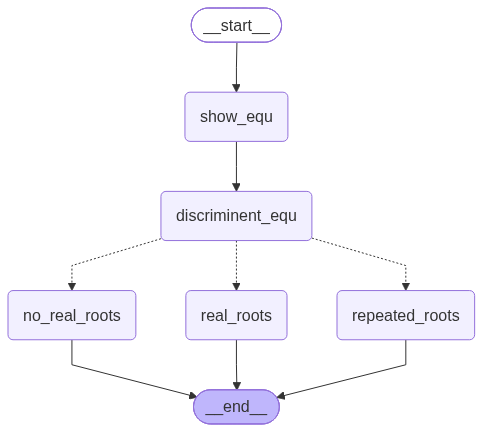

In [63]:
workflow

In [64]:
initial_state = {
    'a': 2, 
    'b': 4,
    'c': 2
}

workflow.invoke(initial_state)

{'a': 2,
 'b': 4,
 'c': 2,
 'equation': '2x24x2',
 'discriminant': 0,
 'result': 'Only repeating root is -1.0'}